In [14]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

(41202, 13)

   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                      1      

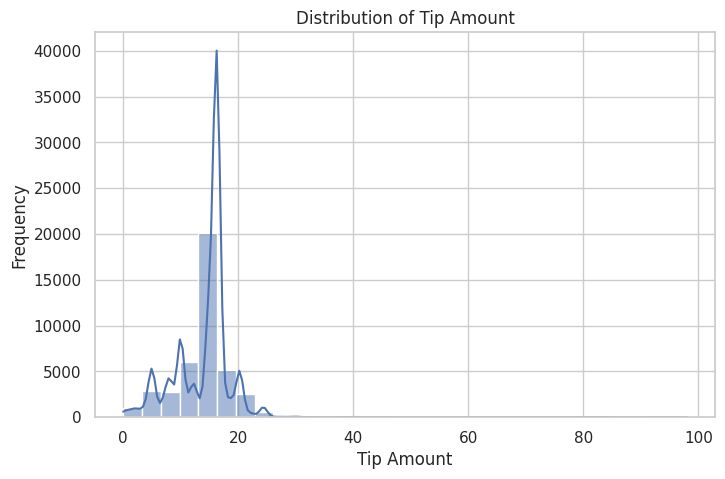

" Student Reasoning — Taxi data exploration What is the shape of the data? Are there missing values or impossible values \n (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? \n How will this influence your preprocessing?\n The shape of the data is (41202, 13) meaning the data contains 41202 rows and 13 olumns.\n From the result of the taxi.isna().sum it shows that there is no row in the data that has a missing value. \n The result for the describe which shows statistical analysis of the data shows that ther are no impossible values for the columns \n such as negative and zeros for columns that couldn't possibly take zeros except for the  trip_distance where we have the minimum \n to be zero. \n The tip_amount distribution right skewed with most tip amounts concentrated between approximately 10 and 20. The histogram shows a \n large peak around 16, indicating that many trips have similar tip values. The distribution 

In [15]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
print(taxi.shape)
print()
print(taxi.head())
print()
taxi.info()
print()
print(taxi.describe())
print()
# count missing values per column:
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize=(8, 5))
sns.histplot(data=taxi, x="tip_amount", bins=30, kde=True)

plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")

plt.show()


""" Student Reasoning — Taxi data exploration What is the shape of the data? Are there missing values or impossible values
 (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)?
 How will this influence your preprocessing?
 The shape of the data is (41202, 13) meaning the data contains 41202 rows and 13 olumns.
 From the result of the taxi.isna().sum it shows that there is no row in the data that has a missing value.
 The result for the describe which shows statistical analysis of the data shows that ther are no impossible values for the columns
 such as negative and zeros for columns that couldn't possibly take zeros except for the  trip_distance where we have the minimum
 to be zero.
 The tip_amount distribution right skewed with most tip amounts concentrated between approximately 10 and 20. The histogram shows a
 large peak around 16, indicating that many trips have similar tip values. The distribution also shows some outliers extending up to 98,
 however the distribution does not contain any zero values. During the process in instances where I have the choice to choose between
 using the median or mean to do something then I will always use the median since the mean is always affected by the outliers which
 might not give me the correct or desired out put I am looking for. If appropriate for the chosen model, the skewness of the target may
 be addressed using a transformation, or outlier treatment may be considered to reduce the influence of extreme values."""

In [16]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
taxi = taxi[taxi["trip_distance"] > 0]
taxi = taxi[taxi["fare_amount"] > 0]
#   decide how to treat negative tip_amount values.
taxi["tip_amount"] = taxi["tip_amount"].fillna(taxi["tip_amount"].median())
"""I will replace those values with the median for the tip_amount, because the tip_amount graph is skewed right and it is better to
use the median to fill the values rather than using mean because the tip+amount contains outliers"""

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"].replace(0, 1)
taxi["total_surcharges"] = taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]
taxi["distance_per_passenger"] = taxi["trip_distance"] / taxi["passenger_count"]

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical = ["VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID"]

numeric = ["passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile",
    "total_surcharges"]

encoded = pd.get_dummies(taxi, columns=categorical, drop_first=True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


"""Student Reasoning — Taxi preprocessing
1. How did you handle missing/invalid rows and why?
For the missing or invalid rows I simply remove rows where the trip distane is equal to zero or less than zero, and also rows that
contains fare amount to be zero or less than zero.

2. Which new feature(s) did you engineer and what is the intuition behind them?
The new feature I engineered is fare_per_mile and total_surchages, and it is done to be able to get the amount each passenger pays for
a mile of distance travel such that passengers do not feel cheated when they see others paying less for their trip, it might be that
they travelles less distance than the other passengers, since the fare_amount or trip_distance on their own alone cannot really tell us
whether passengers are being cheated or not. The next feature is total_surcharges and this is to make it easy for passengers to see how
much amount they have incurred already which can easily inform their decision on how much tip to tip, they can decide to give less tip if
the total surcharges are high or give more tip if their total surcharges are low. The last feature is distance_per_passenger and this is to
capture how much of the trip each passenger effectively used. Such that if a group of passengers take a ride they can easily determine how
much each passenger will pay in accordance to the distance they traveled. Since we cannot easily figure this out from trip_distance and passenger_count
separately dividing them reduces the per-person burden.

3. Which scaling method did you choose and why is it appropriate here?
I chose a StandardScaler because it transforms every numeric column so that it has a mean = 0 and a standard deviation = 1.
It is appropriate because the values in the columns are on different scales and some contain very high values and outliers, so without
using standard scaler it would pay more attention to the coulmns with high values not because they are more important but just
because of their values."""

'Student Reasoning — Taxi preprocessing \n1. How did you handle missing/invalid rows and why? \nFor the missing or invalid rows I simply remove rows where the trip distane is equal to zero or less than zero, and also rows that \ncontains fare amount to be zero or less than zero.\n\n2. Which new feature(s) did you engineer and what is the intuition behind them? \nThe new feature I engineered is fare_per_mile and total_surchages, and it is done to be able to get the amount each passenger pays for \na mile of distance travel such that passengers do not feel cheated when they see others paying less for their trip, it might be that \nthey travelles less distance than the other passengers, since the fare_amount or trip_distance on their own alone cannot really tell us \nwhether passengers are being cheated or not. The next feature is total_surcharges and this is to make it easy for passengers to see how \nmuch amount they have incurred already which can easily inform their decision on how mu

In [17]:
# TODO: Separate features (X) and target (y = tip_amount)
X = encoded.drop(columns=["tip_amount"])
y = encoded["tip_amount"]

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split
Xremain, Xtest, Yremain, Ytest = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

Xtrain, Xval, Ytrain, Yval = train_test_split(
    Xremain, Yremain, test_size=0.25, random_state=RANDOM_STATE)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
Xtrain[numeric] = scaler.fit_transform(Xtrain[numeric])
Xval[numeric] = scaler.transform(Xval[numeric])
Xtest[numeric] = scaler.transform(Xtest[numeric])
""" Scalling should be fit on train only because it learns the mean and standard deviation of the data and if it is fit on the whole
data meaning it is going to get the mean and standard deviation of the test and validation data which it wasn't supposed to see. """



" Scalling should be fit on train only because it learns the mean and standard deviation of the data and if it is fit on the whole \ndata meaning it is going to get the mean and standard deviation of the test and validation data which it wasn't supposed to see. "

Prediction for training data [14.50519168 15.14567711 14.96434672 ... 14.37842613 14.66087911
 14.30676596]

Prediction for validation data [13.11240853 14.13008165 13.27440117 ... 14.25743319 14.34868274
 13.84821733]

Prediction for testing data [13.02338832 18.13784666 15.24856539 ... 13.95568072 14.40412566
 11.0652836 ]
RMSE for the training data 4.775631649028426

RMSE for the validation data 5.045695738681703

RMSE for the testing data 5.015745790083556
r2 for the training data 0.0626755887976348

r2 for the validation data 0.04539865707598878

r2 for the testing data 0.05009005402202393


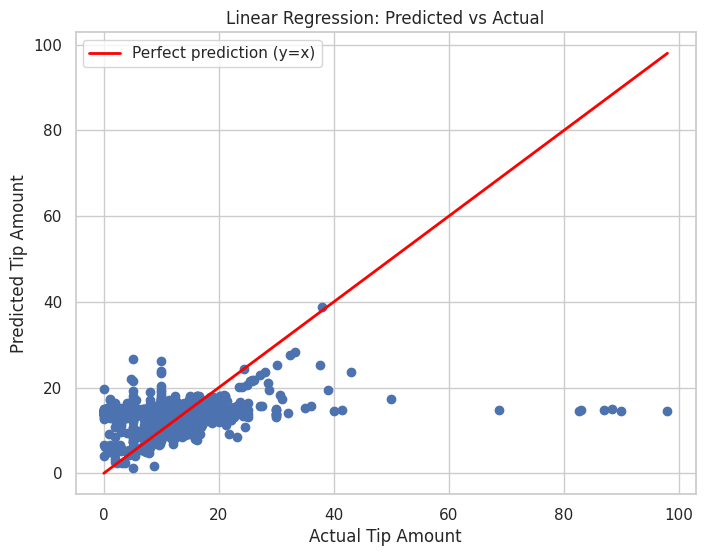

In [18]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

LRmodel = LinearRegression()
LRmodel.fit(Xtrain, Ytrain)


# TODO: Predict on train, validation, and test sets.
LRPredTrain = LRmodel.predict(Xtrain)
print("Prediction for training data", LRPredTrain)
print()
LRPredVal = LRmodel.predict(Xval)
print("Prediction for validation data",LRPredVal)
print()
LRPredTest = LRmodel.predict(Xtest)
print("Prediction for testing data",LRPredTest)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
LRtrainRMSE = mean_squared_error(Ytrain, LRPredTrain) ** 0.5
print("RMSE for the training data", LRtrainRMSE)
print()
LRvalRMSE = mean_squared_error(Yval, LRPredVal)   ** 0.5
print("RMSE for the validation data", LRvalRMSE)
print()
LRtestRMSE = mean_squared_error(Ytest, LRPredTest)  ** 0.5
print("RMSE for the testing data", LRtestRMSE)

LRtrain_r2   = r2_score(Ytrain, LRPredTrain)
print("r2 for the training data", LRtrain_r2)
print()
LRval_r2     = r2_score(Yval, LRPredVal)
print("r2 for the validation data",LRval_r2)
print()
LRtest_r2    = r2_score(Ytest, LRPredTest)
print("r2 for the testing data", LRtest_r2)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 6))
plt.scatter(Ytest, LRPredTest,)

plt.plot([Ytest.min(), Ytest.max()],
    [Ytest.min(), Ytest.max()], color="red",
    linewidth=2, label="Perfect prediction (y=x)")

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title(f"Linear Regression: Predicted vs Actual")
plt.legend()
plt.show()

Prediction for training data [13.418225   14.8222     16.29999167 ... 10.95833384 11.70221333
 16.38578333]

Prediction for training data [14.0776     13.90513333 15.37661333 ... 13.04300667 16.1543
 13.32127845]

Prediction for training data [12.20878333 16.47899762 15.7226     ... 16.40222833 14.62896226
 11.8724    ]
RMSE for the training data 2.8413859187322386

RMSE for the validation data 5.644670599065988

RMSE for the testing data 5.645262352188406
r2 for the training data 0.6681905642005183

r2 for the validation data -0.19469523221210583

r2 for the testing data -0.20331591230920298


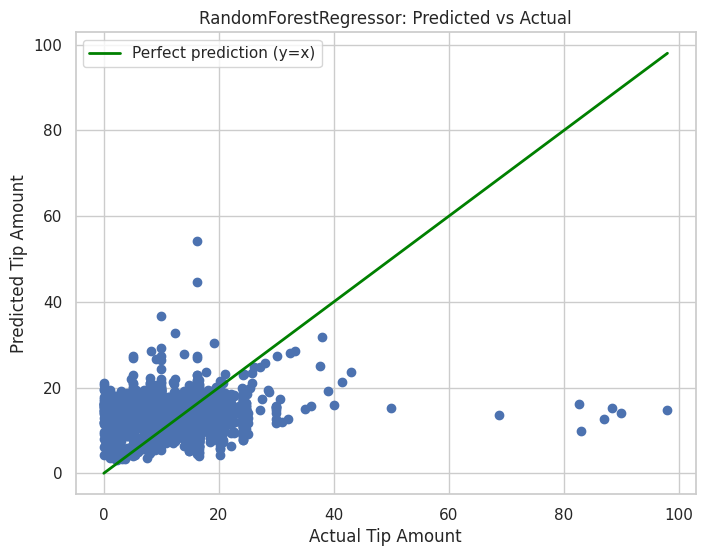

"Student Reasoning — Regression evaluation & overfitting \n1. Which model performed best on the validation set, and which \nhyper-parameters did you try? \nThe linear regression model performed best on the validatio set with a lower RMSE of 5.045695738681703 and a higher r2 of \n0.04539865707598878 as compared to the random forest regressor which had RMSE to be 5.644670599065988 and r2 to be -0.1946952322121058. \nFor hyperparameters, Linear Regression was used with default settings. Random Forest was initialised with n_estimators=100 \n(100 decision trees in the forest) and a fixed random_state.\n\n2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers \nthat back up your claim. \nLinear Regression: The model is does not appear to be over fitting because the RMSE of all the three data sets do not have a vast \ndifference amongst them as well as their r2 values however their r2's appear to be vey low accross al

In [19]:
from sklearn.ensemble import RandomForestRegressor

RFmodel = RandomForestRegressor(n_estimators=100,
    random_state=RANDOM_STATE)
RFmodel.fit(Xtrain, Ytrain)

RFPredTrain = RFmodel.predict(Xtrain)
print("Prediction for training data", RFPredTrain)
print()
RFPredVal = RFmodel.predict(Xval)
print("Prediction for training data", RFPredVal)
print()
RFPredTest = RFmodel.predict(Xtest)
print("Prediction for training data", RFPredTest)


RFTrainrmse = mean_squared_error(Ytrain, RFPredTrain) ** 0.5
print("RMSE for the training data", RFTrainrmse)
print()
RFValrmse = mean_squared_error(Yval, RFPredVal)   ** 0.5
print("RMSE for the validation data", RFValrmse)
print()
RFTestrmse = mean_squared_error(Ytest, RFPredTest)  ** 0.5
print("RMSE for the testing data", RFTestrmse)


RFTrain_r2 = r2_score(Ytrain, RFPredTrain)
print("r2 for the training data", RFTrain_r2)
print()
RFVal_r2 = r2_score(Yval, RFPredVal)
print("r2 for the validation data",RFVal_r2)
print()
RFTest_r2 = r2_score(Ytest, RFPredTest)
print("r2 for the testing data", RFTest_r2)

plt.figure(figsize=(8, 6))
plt.scatter(Ytest, RFPredTest,)

plt.plot([Ytest.min(), Ytest.max()],
    [Ytest.min(), Ytest.max()], color="green",
    linewidth=2, label="Perfect prediction (y=x)")

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title(f"RandomForestRegressor: Predicted vs Actual")
plt.legend()
plt.show()

"""Student Reasoning — Regression evaluation & overfitting
1. Which model performed best on the validation set, and which
hyper-parameters did you try?
The linear regression model performed best on the validatio set with a lower RMSE of 5.045695738681703 and a higher r2 of
0.04539865707598878 as compared to the random forest regressor which had RMSE to be 5.644670599065988 and r2 to be -0.1946952322121058.
For hyperparameters, Linear Regression was used with default settings. Random Forest was initialised with n_estimators=100
(100 decision trees in the forest) and a fixed random_state.

2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers
that back up your claim.
Linear Regression: The model is does not appear to be over fitting because the RMSE of all the three data sets do not have a vast
difference amongst them as well as their r2 values however their r2's appear to be vey low accross all the data sets indicating that
the model generalizes consistently to unseen data, but the low r2 suggest the model explains only about 5% of the variation of the
target variable. The metrics supporting this conclusion are:
RMSE for traning data: 4.775631649028426, RMSE for validation data: 5.045695738681703, and RMSE for testing data: 5.015745790083556.
r2 for training data: 0.0626755887976348, r2 for validation data: 0.04539865707598878, and r2 for testing data: 0.05009005402202393.
Random Forest Regressor: The model overfitted, memorized the data instead of generalizing. The massive difference in the RMSE and r2
amongst the training data set and the other two data sets. These results suggest that the model memorized patterns in the training data instead of learning
patterns that generalize well to new data..
The metrics supporting this conclusion are:
RMSE for the training data: 2.8413859187322386, RMSE for the validation data: 5.644670599065988, and RMSE for the testing data: 5.645262352188406.
r2 for the training data: 0.6681905642005183, r2 for the validation data: -0.19469523221210583, r2 for the testing data -0.20331591230920298.

3. What would you change to reduce overfitting if you saw it?
To reduce overfitting, I would make the model simpler so that it learns the general patterns in the data instead of memorizing the training data.
I would limit how complex the decision trees become and ensure that each decision is based on enough data."""

(2111, 17)

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transporta

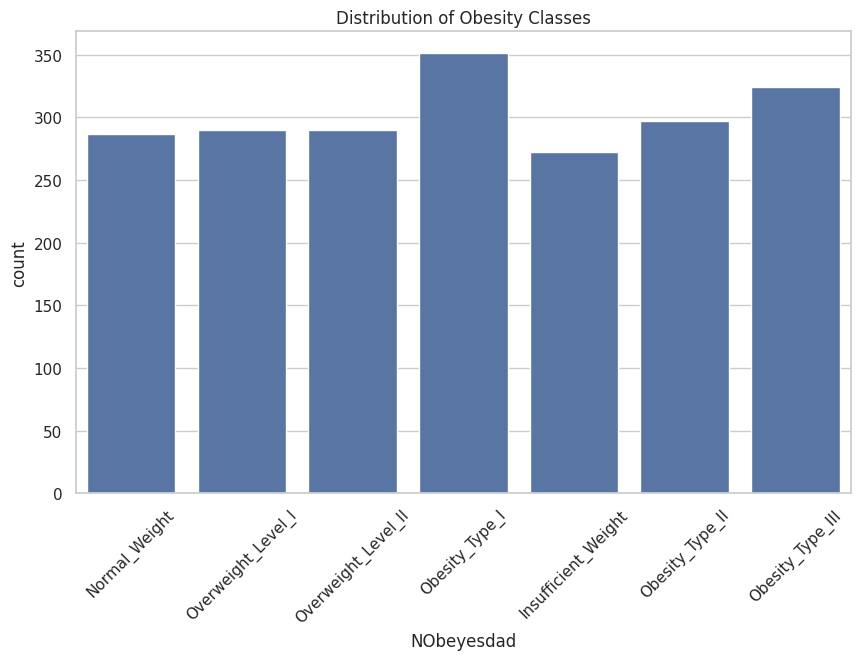

'Student Reasoning — Obesity data exploration How many rows/features are there? \nThere are 2111 rows and 17 columns.\nWhich columns are categorical vs numeric? \nNumeric: Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE\nCategorical: Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, NObeyesdad.\n\nIs the target balanced across the 7 classes, and why does class (im)balance matter for classification?\nYes it is balanced across the 7 classes, class imbalance matters because models tend to favor the majority \nclass, since they try to minimize overall error. This can lead to good accuracy but poor performance on minority classes, \nmaking predictions unreliable for less common groups.'

In [20]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print(obesity.shape)
print()
print(obesity.head())
print()
obesity.info()
print()
print(obesity.describe())
print()
print(obesity.isna().sum())
print()


# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
""" yes it is balance accross the 7 classes"""
print(obesity["NObeyesdad"].value_counts())
print()
plt.figure(figsize=(10,6))

sns.countplot(x="NObeyesdad", data=obesity)

plt.title("Distribution of Obesity Classes")
plt.xticks(rotation=45)
plt.show()

"""Student Reasoning — Obesity data exploration How many rows/features are there?
There are 2111 rows and 17 columns.
Which columns are categorical vs numeric?
Numeric: Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE
Categorical: Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, NObeyesdad.

Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?
Yes it is balanced across the 7 classes, class imbalance matters because models tend to favor the majority
class, since they try to minimize overall error. This can lead to good accuracy but poor performance on minority classes,
making predictions unreliable for less common groups."""


In [21]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

from sklearn.preprocessing import LabelEncoder
binary_columns = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_columns:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})


obesity["Gender"] = obesity["Gender"].map({"Male": 1, "Female": 0})

caec = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}

obesity["CAEC"] = obesity["CAEC"].map(caec)
obesity["CALC"] = obesity["CALC"].map(calc)

obesity = pd.get_dummies(obesity, columns=["MTRANS"], drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)


# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
obesity["NObeyesdad_encoded"] = label.fit_transform(obesity["NObeyesdad"])

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

"""Student Reasoning — Obesity preprocessing
1. How did you encode each type of categorical variable, and why?
Binary columns (family_history_with_overweight, FAVC, SMOKE, SCC, Gender) were mapped to 0/1 because they only have two values.CAEC and
CALC were given ordinal numbers (0,1,2,3) because they have a natural order from no consumption to always consuming. MTRANS was one-hot
encoded with get_dummies because it has multiple categories with no meaningful order treating them as numbers would imply a false ranking.

2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level.
Yes, I added BMI = Weight / Height². It is fair to include because it is calculated from Weight and Height which are already input
features, not from the target column NObeyesdad. But because BMI is closely related to obesity level it might make the task easier
making the model to rely on it.

3. Which scaler did you use and why?
I chose a StandardScaler because it transforms every numeric column so that it has a mean = 0 and a standard deviation = 1. It was used
to prevent larger valued columns like Weight from dominating over smaller ones like Height or Age."""





'Student Reasoning — Obesity preprocessing \n1. How did you encode each type of categorical variable, and why? \nBinary columns (family_history_with_overweight, FAVC, SMOKE, SCC, Gender) were mapped to 0/1 because they only have two values.CAEC and \nCALC were given ordinal numbers (0,1,2,3) because they have a natural order from no consumption to always consuming. MTRANS was one-hot \nencoded with get_dummies because it has multiple categories with no meaningful order treating them as numbers would imply a false ranking.\n\n2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level. \nYes, I added BMI = Weight / Height². It is fair to include because it is calculated from Weight and Height which are already input \nfeatures, not from the target column NObeyesdad. But because BMI is closely related to obesity level it might make the task easier \nmaking the model to rely on it.\n\n3. Which scaler did you use and why?\nI chose a 

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate X (features) and y (encoded NObeyesdad).

X_ob = obesity.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])
y_ob = obesity["NObeyesdad_encoded"]

numeric_ob = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE", "BMI"]

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

X_ob_remain, X_ob_test, y_ob_remain, y_ob_test = train_test_split(
    X_ob, y_ob, test_size=0.20, random_state=RANDOM_STATE, stratify=y_ob)

X_ob_train, X_ob_val, y_ob_train, y_ob_val = train_test_split(
    X_ob_remain, y_ob_remain, test_size=0.25, random_state=RANDOM_STATE, stratify=y_ob_remain)

# TODO: Fit the scaler on the training set only, then transform train / val / test.

ob_scaler = StandardScaler()

X_ob_train[numeric_ob] = ob_scaler.fit_transform(X_ob_train[numeric_ob])
X_ob_val[numeric_ob] = ob_scaler.transform(X_ob_val[numeric_ob])
X_ob_test[numeric_ob] = ob_scaler.transform(X_ob_test[numeric_ob])


"""Student Reasoning — Splitting What split ratio did you choose?
I used 60% for the training, 20% for validation and the last 20% for testing. This division give the model enough data to learn from such that it will be able to generalise and make accurate predictions.
Why is stratify=y important for this dataset?
stratify=y forces every split to contain the same proportion of each class as the full dataset. Because the data has several classes and a random split can put very few examples of one class into the validation or test and the model would not be able to predict that class well


What could go wrong if you split without stratifying?
Some classes of might be missing from the validation or test data set. The model would look like it performs
well overall but would completely fail on the missing classes in real use. """

'Student Reasoning — Splitting What split ratio did you choose? \nI used 60% for the training, 20% for validation and the last 20% for testing. This division give the model enough data to learn from such that it will be able to generalise and make accurate predictions.\nWhy is stratify=y important for this dataset? \nstratify=y forces every split to contain the same proportion of each class as the full dataset. Because the data has several classes and a random split can put very few examples of one class into the validation or test and the model would not be able to predict that class well\n\n\nWhat could go wrong if you split without stratifying?\nSome classes of might be missing from the validation or test data set. The model would look like it performs\nwell overall but would completely fail on the missing classes in real use. '

RANDOM FOREST CLASSIFIER RESULTS

1.0

0.990521327014218

0.9881796690307328

1.0

0.9899463863622177

0.9880578169437122

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        54
      Normal_Weight       0.97      0.98      0.97        58
     Obesity_Type_I       0.99      0.99      0.99        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      0.97      0.98        58
Overweight_Level_II       0.98      1.00      0.99        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



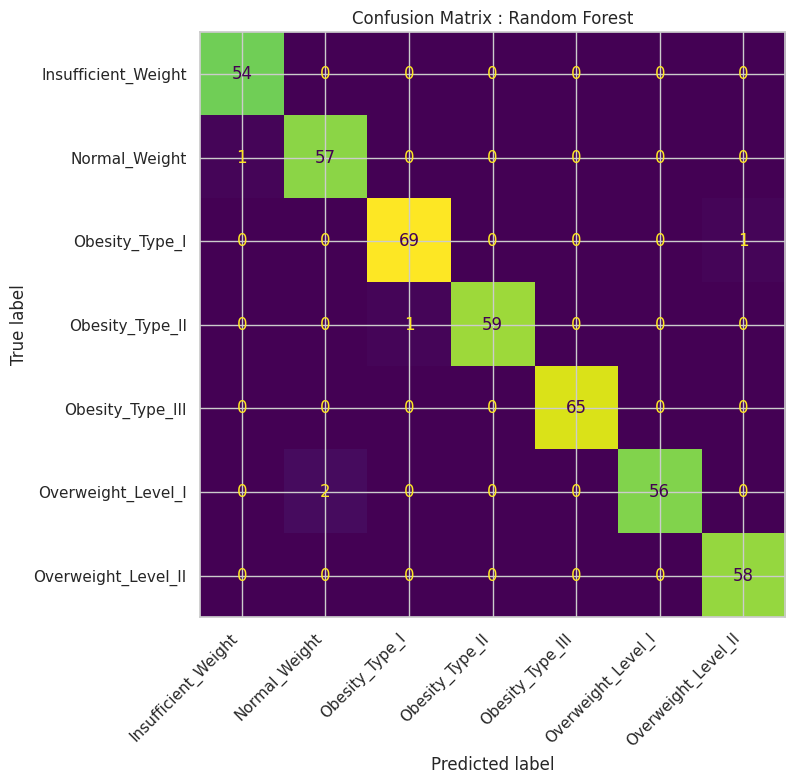

'Student Reasoning — Classification evaluation & overfitting \n1. Which classifier did you choose and why? \nI choose random forest classifier because it can handle both numeric and categorical features well and it is better in terms of \noverfitting than a decision tree.\n\n2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics. \nThe model is well fitted since there are no much difference in the accuracy and F1 values of all the three data sets. The metrics that \ninformed this decision are as follow;\ntrain accuracy: 1.0, validation accuracy: 0.990521327014218, and test accuracy: 0.9881796690307328\ntraining F1: 1.0, validation F1: 0.9899463863622177, and test F1: 0.9880578169437122\n\n3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?\nThe most confused classes were Overweight_Level_I, where 2 people were incorrectly predicted as Normal_Weight, and Normal

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

RF_classifier = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE)
RF_classifier.fit(X_ob_train, y_ob_train)

# TODO: Predict on train, validation, and test.

RF_pred_train = RF_classifier.predict(X_ob_train)
RF_pred_val = RF_classifier.predict(X_ob_val)
RF_pred_test = RF_classifier.predict(X_ob_test)


# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

print("RANDOM FOREST CLASSIFIER RESULTS")
print()
train_acc = accuracy_score(y_ob_train, RF_pred_train)
print(train_acc)
print()
val_acc = accuracy_score(y_ob_val, RF_pred_val)
print(val_acc)
print()
test_acc = accuracy_score(y_ob_test, RF_pred_test)
print(test_acc)
print()

train_f1  = f1_score(y_ob_train, RF_pred_train, average="macro")
print(train_f1)
print()
val_f1 = f1_score(y_ob_val,   RF_pred_val, average="macro")
print(val_f1)
print()
test_f1 = f1_score(y_ob_test,  RF_pred_test, average="macro")
print(test_f1)
print()

print("Classification Report:")
print(classification_report(y_ob_test, RF_pred_test, target_names=label.classes_ ))


# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?


fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(y_ob_test, RF_pred_test, display_labels=label.classes_, ax=ax,
    colorbar=False)

plt.title("Confusion Matrix : Random Forest")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


"""Student Reasoning — Classification evaluation & overfitting
1. Which classifier did you choose and why?
I choose random forest classifier because it can handle both numeric and categorical features well and it is better in terms of
overfitting than a decision tree.

2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics.
The model is well fitted since there are no much difference in the accuracy and F1 values of all the three data sets. The metrics that
informed this decision are as follow;
train accuracy: 1.0, validation accuracy: 0.990521327014218, and test accuracy: 0.9881796690307328
training F1: 1.0, validation F1: 0.9899463863622177, and test F1: 0.9880578169437122

3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?
The most confused classes were Overweight_Level_I, where 2 people were incorrectly predicted as Normal_Weight, and Normal_Weight where 1
person was incorrectly classified as Insufficient_Weight. Similarly 1 Obesity_Type_II case was misclassified as Obesity_Type_I.
These confusions all happen between neighbouring classes"""


k=2  inertia=10860.203014156268
k=3  inertia=9773.646593996862
k=4  inertia=8949.428343913463
k=5  inertia=8187.259358440725
k=6  inertia=7692.404198688892
k=7  inertia=7322.110464368555
k=8  inertia=7034.6527807604
k=9  inertia=6778.886344619443
k=10  inertia=6494.935477778616


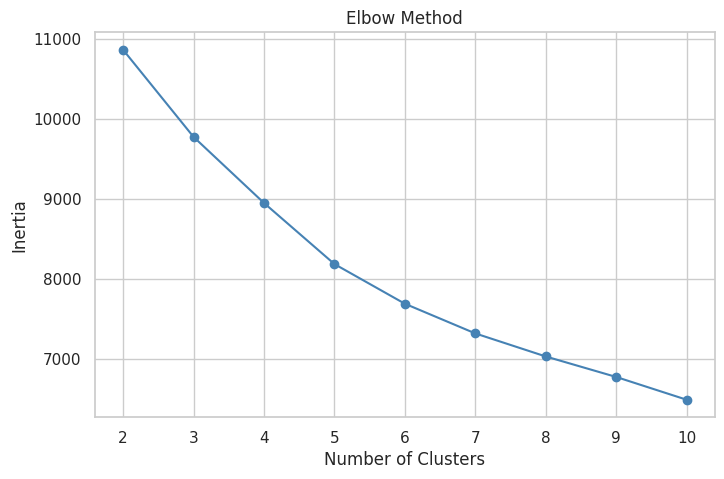

Chosen k: 7


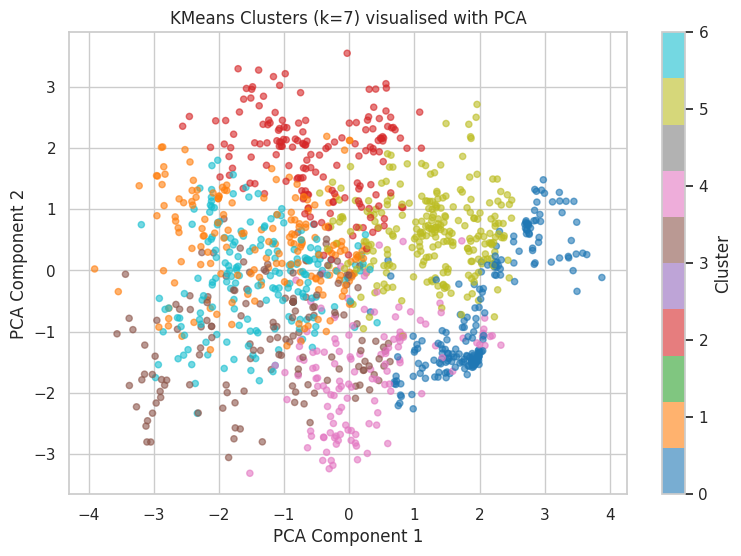

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = X_ob_train.copy()

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_cluster)
    inertia_values.append(kmeans.inertia_)
    print(f"k={k}  inertia={kmeans.inertia_}")

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o", color="steelblue")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

best_k = 7

final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_cluster)

print(f"Chosen k: {best_k}")


# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_cluster)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
    c=cluster_labels, cmap="tab10", alpha=0.6, s=20)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"KMeans Clusters (k={best_k}) visualised with PCA")
plt.show()


Cluster vs Real Obesity Level:
Real Obesity Level  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Cluster                                                                  
0                                     0              0               1   
1                                    39             39              26   
2                                    44             37              22   
3                                    23             31              27   
4                                     0              4              39   
5                                     0              2              81   
6                                    57             59              15   

Real Obesity Level  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Cluster                                                                     
0                                 6               194                   0   
1                                 0                 0                  

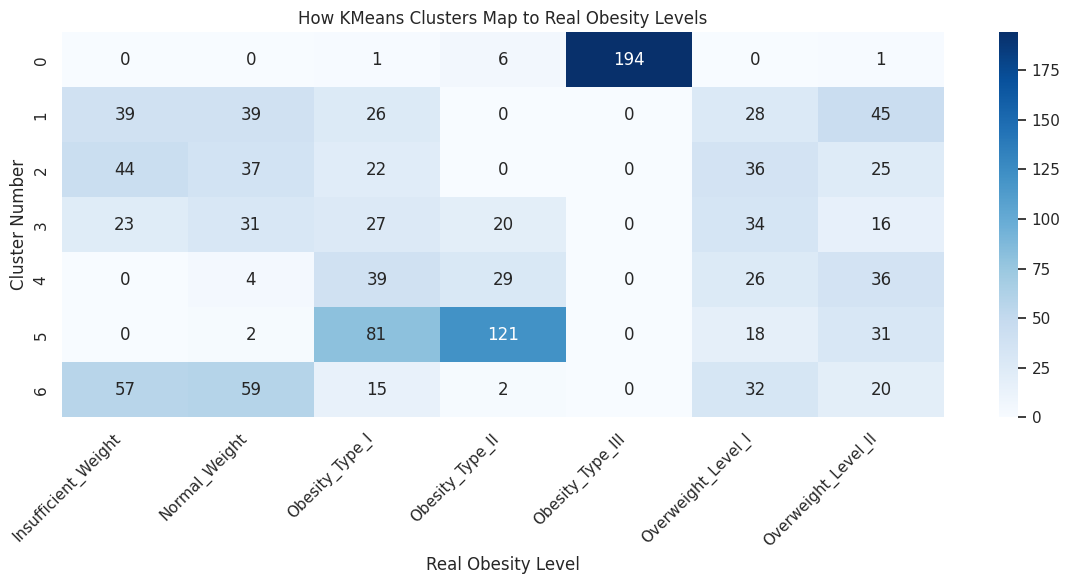

'Student Reasoning — Clustering \n1. How did you choose k? Quote the Elbow/silhouette evidence. \nMy choice of k was influenced by the elbow plot which showed inertia dropping steeply from k=2 through to around k=6 or k=7, after \nwhich the curve began to flatten out, meaning adding more clusters beyond 7 produced diminishing returns in terms of how much tighter \nthe clusters became. \n\n2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they \nbreak down? \nLooking at the crosstab, the unsupervised clusters broadly resemble the real obesity levels, which is remarkable given that KMeans \nnever saw a single label during training. Several clusters map quite cleanly onto specific obesity classes, for example one cluster \ncontains the majority of Obesity_Type_III cases and another captures most Insufficient_Weight cases. This agreement happens because \nThese extreme classes (very obese and very underweight) have c

In [25]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
real_labels = obesity["NObeyesdad"].iloc[X_ob_train.index]

crosstab = pd.crosstab(cluster_labels, real_labels, rownames=["Cluster"], colnames=["Real Obesity Level"])

print("Cluster vs Real Obesity Level:")
print(crosstab)

plt.figure(figsize=(12, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
plt.title("How KMeans Clusters Map to Real Obesity Levels")
plt.ylabel("Cluster Number")
plt.xlabel("Real Obesity Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

"""Student Reasoning — Clustering
1. How did you choose k? Quote the Elbow/silhouette evidence.
My choice of k was influenced by the elbow plot which showed inertia dropping steeply from k=2 through to around k=6 or k=7, after
which the curve began to flatten out, meaning adding more clusters beyond 7 produced diminishing returns in terms of how much tighter
the clusters became.

2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they
break down?
Looking at the crosstab, the unsupervised clusters broadly resemble the real obesity levels, which is remarkable given that KMeans
never saw a single label during training. Several clusters map quite cleanly onto specific obesity classes, for example one cluster
contains the majority of Obesity_Type_III cases and another captures most Insufficient_Weight cases. This agreement happens because
These extreme classes (very obese and very underweight) have clearly distinct feature values.
However the clusters break down most noticeably in the middle of the obesity scale, specifically between Overweight_Level_I,
Overweight_Level_II and Obesity_Type_I. These three classes sit so close together in terms of actual feature values that KMeans cannot
cleanly separate them. People from these three real classes often end up mixed together in the same cluster because from a pure distance/
similarity point of view they genuinely look alike.

3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?
KMeans clustering would be useful here to help identify groups of people with similar health risk profiles using only raw measurements
without needing a doctor to label anyone. It could specifically be used to design targeted public health campaign, screen large
populations cheaply, and people in the high-risk cluster could be automatically flagged for early medical intervention."""

In [26]:
"""Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
The Random Forest Classifier learned the specific boundaries between the 7 obesity levels by being shown labelled examples during
training, meaning it learned which combinations of features like Weight, Height, BMI, CAEC and CALC correspond to which obesity level.
This is why it achieved a test accuracy of 0.9882 and a test macro F1 of 0.9881, correctly classifying almost every single person in
the test set. KMeans could not do this because it never saw a single label during training, it could only group people based on how
similar their feature values were to each other.

What KMeans found that the classifier could not is the natural structure of the data without any human guidance. It revealed that the
obesity data naturally separates into groups based on similarity, and that these groups broadly align with the real obesity levels even
without being told what those levels are. The classifier cannot do this because it always depends on labels to learn from, so it can
only see the patterns that humans have already defined through the labelling process.

Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?

For the taxi tip prediction task which is a regression problem, I used RMSE and R² to evaluate the models. The R² of around 0.05 across
all three sets told me the model only explained about 5% of the variation in tip amounts which was poor. With regression there is no right or wrong answer, predictions are just closer or further
from the true value on a continuous scale.

For the obesity classification task I used accuracy and macro F1. Accuracy told me the percentage of obesity classes predicted exactly
right, and macro F1 measured performance on each of the 7 classes separately and averaged them equally. A prediction in classification
is either exactly right or exactly wrong with no in between, unlike regression where a prediction of 14 dollars
for an actual tip of 16 dollars is close even though it is not exactly right. The macro F1 was especially important here because the
dataset has 7 classes and I needed to make sure the model was not just doing well on the common classes while failing on the rarer ones.


Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you
did (or would do) to close it?
The biggest train vs test gap appeared in the Random Forest Regressor for the taxi tip prediction task. The training R² was
0.6681905642005183 but the validation R² dropped massively to -0.19469523221210583 and the test R² was -0.20331591230920298. Similarly
the training RMSE was 2.8413859187322386 but the validation RMSE jumped to 5.644670599065988 and the test RMSE was 5.645262352188406.
This massive difference between the training results, validation and test results shows that the Random Forest Regressor memorised the
training data instead of learning general patterns that transfer to new data.

The single most effective thing I would do to close this gap is to limit how deep the trees in the Random Forest can grow by setting
the max_depth parameter. Shallower trees cannot memorise the fine details of the training data and are forced to learn broader patterns
that generalise better to new unseen data. This directly addresses the root cause of the overfitting which was the model becoming too
complex and fitting too closely to the specific trips in the training set."""

'Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?\nThe Random Forest Classifier learned the specific boundaries between the 7 obesity levels by being shown labelled examples during \ntraining, meaning it learned which combinations of features like Weight, Height, BMI, CAEC and CALC correspond to which obesity level. \nThis is why it achieved a test accuracy of 0.9882 and a test macro F1 of 0.9881, correctly classifying almost every single person in \nthe test set. KMeans could not do this because it never saw a single label during training, it could only group people based on how \nsimilar their feature values were to each other.\n\nWhat KMeans found that the classifier could not is the natural structure of the data without any human guidance. It revealed that the \nobesity data naturally separates into groups based on similarity, and that these groups broadly align with the real obesity levels even \nwithout being told what those levels